In [1]:
import matplotlib.pyplot as plt
from neurodsp.spectral import compute_spectrum_welch
from specparam.plts import plot_spectra

from neurodsp.plts import plot_time_series
from dissertation_simulations.cz_signal_simulations import generate_cz_signal_ap
from dissertation_simulations.cz_signal_simulations import generate_cz_signal_full

from dissertation_simulations.params import freq_range

from dissertation_simulations.generate_1D_electrodes import generate_1D_electrodes_ap
from dissertation_simulations.generate_1D_electrodes import generate_1D_electrodes_full

from dissertation_simulations.time_series import plot_multiple_time_series
from dissertation_simulations.time_series import avg_ts

from dissertation_simulations.psd import avg_psd

from dissertation_simulations.spec_mod import avg_specmod_exp

#### Generate aperiodic signal function

In [2]:
# Generate signal and get params
cz_signal_ap, params, times = generate_cz_signal_ap()

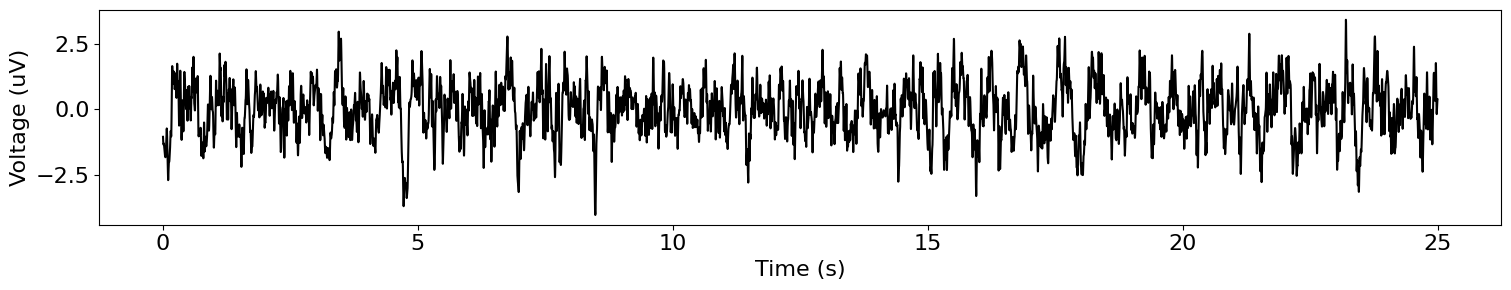

In [3]:
plot_time_series(times, cz_signal_ap)

#### Generate aperiodic and periodic signal

In [4]:
cz_signal_full, params, times = generate_cz_signal_full()

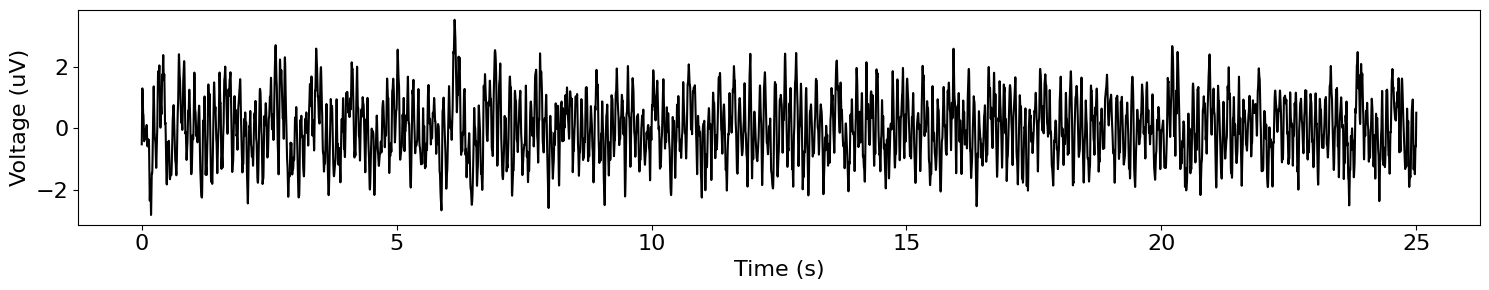

In [5]:
plot_time_series(times, cz_signal_full)

#### Generate 1D electrode signal - aperiodic

In [6]:
exponents = [-1, -1, -1]
signals, params_list, times = generate_1D_electrodes_ap(3, exponents)

In [7]:
exponents = [-2, -1.5, -1.25, -1]
signals, params_list, times = generate_1D_electrodes_ap(4, exponents)

#### Generate 1D electrode signal - full

In [8]:
exponents = [-1, -1, -1]
signals, params_list, times = generate_1D_electrodes_full(3, exponents)

In [9]:
exponents = [-2, -1.5, -1.25, -1]
signals, params_list, times = generate_1D_electrodes_full(4, exponents)

#### Plot multiple time series

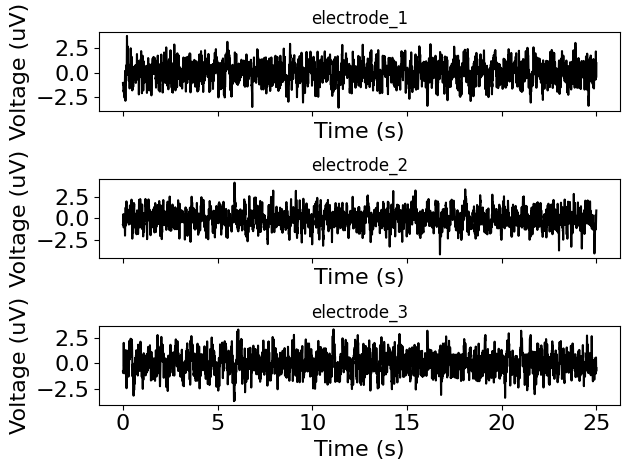

In [10]:
# Generate 1D array of electrodes 
exponents = [-1, -1, -1]
signals, params_list, times = generate_1D_electrodes_ap(3, exponents)

# Plot time series
plot_multiple_time_series(signals, times)

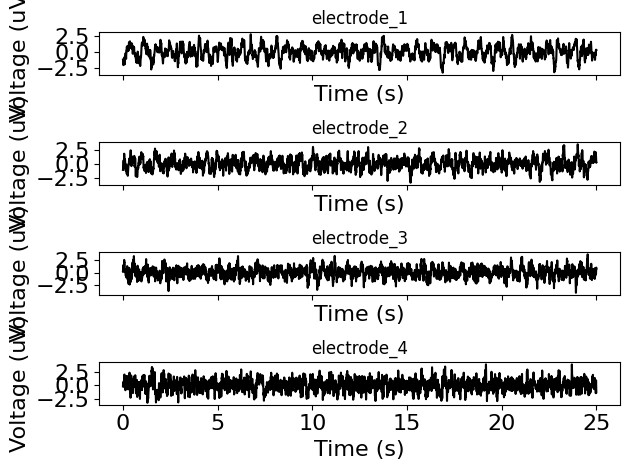

In [11]:
# Generate 1D array of electrodes 
exponents = [-2, -1.5, -1.25, -1]
signals, params_list, times = generate_1D_electrodes_ap(4, exponents)

# Plot time series
plot_multiple_time_series(signals, times)

#### Average time series

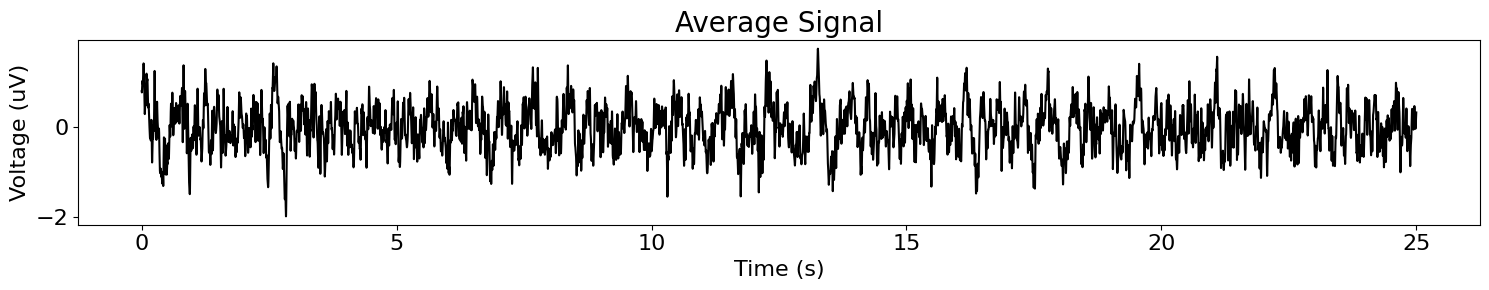

In [12]:
# Generate 1D array of electrodes 
exponents = [-2, -1.5, -1.25, -1]
signals, params_list, times = generate_1D_electrodes_ap(4, exponents)

# Plot time series
avg_ts(signals, times)

#### Average PSD

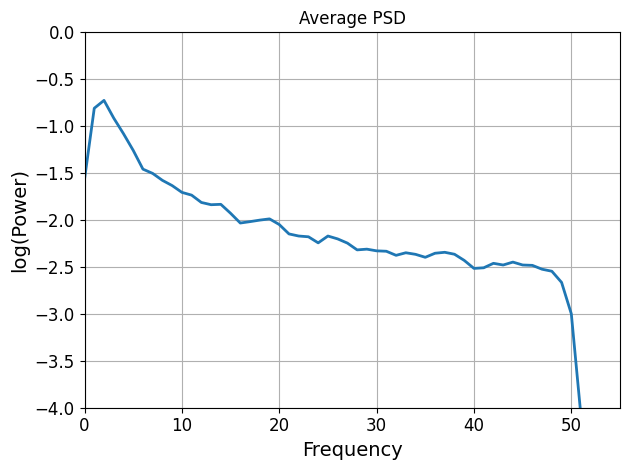

In [13]:
# Generate 1D array of electrodes 
exponents = [-2, -1.5, -1.25, -1]
signals, params_list, times = generate_1D_electrodes_ap(4, exponents)

# Compute and plot average PSD
psds, avg_powers, freqs = avg_psd(signals, params)

#### Average exponent from Spectral Models

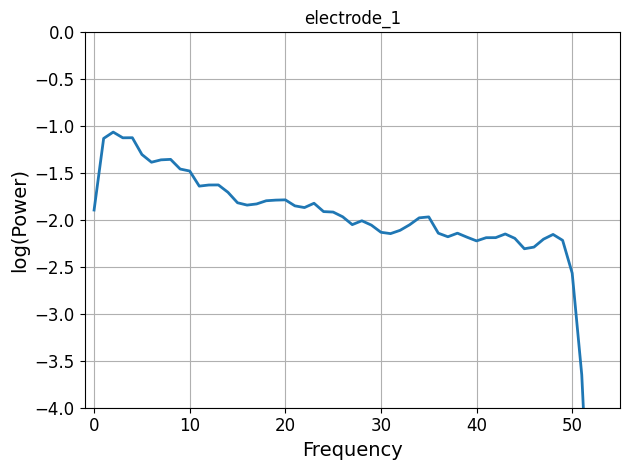

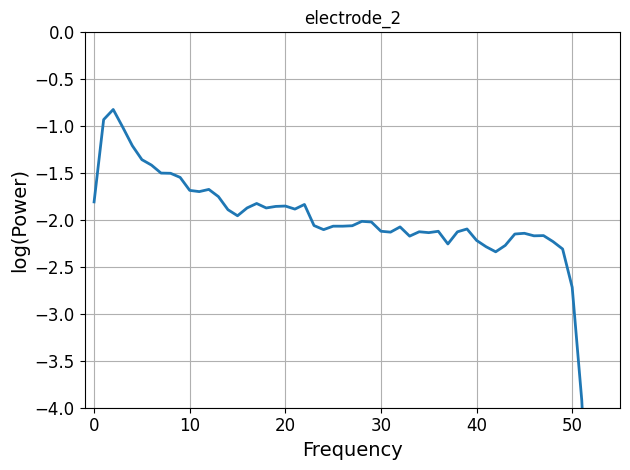

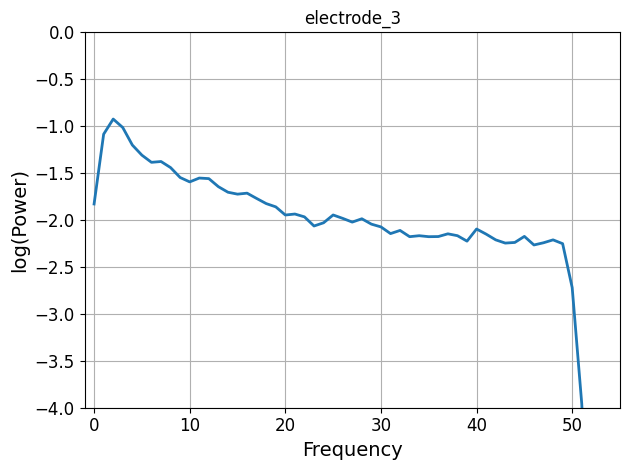


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, 

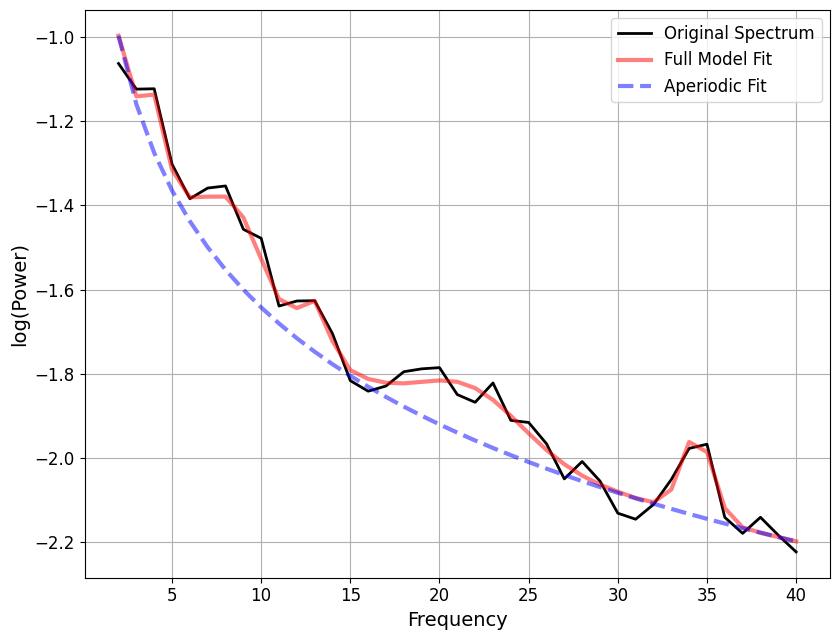

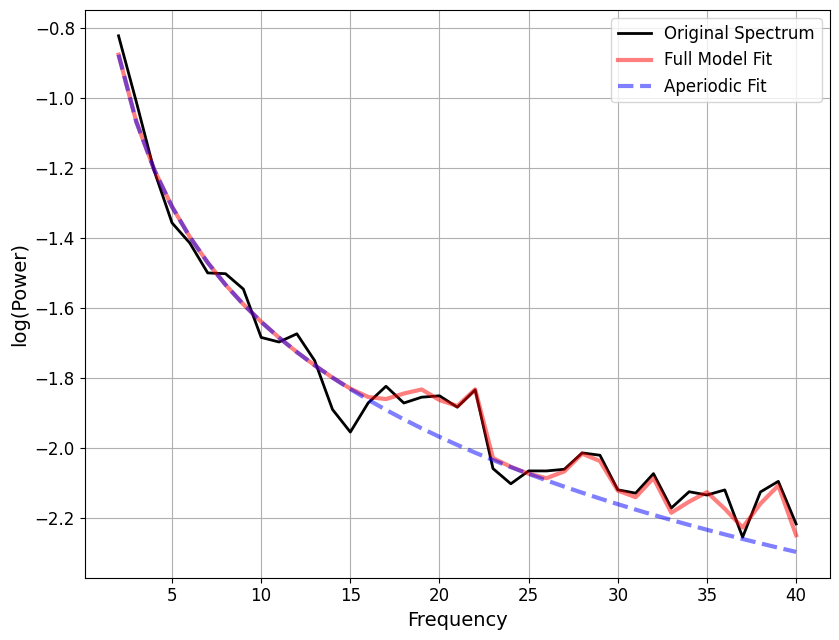

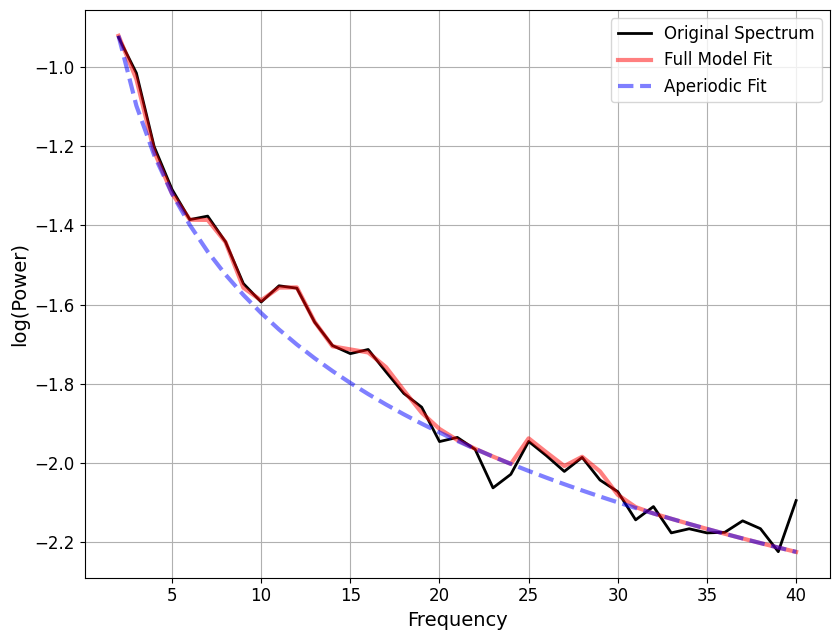

In [14]:
# Generate 1D array of electrodes
exponents = [-1, -1, -1]
signals, params_list, times = generate_1D_electrodes_ap(3, exponents)

# Compute PSDs for each 
from dissertation_simulations.params import cz_sim_params_ap
from dissertation_simulations.params import welch_params

psds = {}

params = cz_sim_params_ap.copy()
welch_dict = welch_params(params)

for name, signal in signals.items():
    fig, ax = plt.subplots()
    freqs, powers = compute_spectrum_welch(signal, fs=params["s_rate"], **welch_dict)
    
    psds[name] = (freqs, powers)
    plot_spectra(freqs, powers, log_powers=True, ax=ax)

    ax.set_title(name)
    ax.set_xlim(-1, 55)
    ax.set_ylim(-4, 0)

    plt.show()

# Compute average exponent from Spectral Models
spectral_models, exponents, avg_exponent = avg_specmod_exp(psds, freq_range= freq_range)